# 📘 Analysis of Stochastic Sampling Results for keff

In [1]:
import h5py
import tarfile
from io import BytesIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.stats as stats

## OpenMC Nuclear Data Uncertainty Propagation

This notebook analyzes the propagation of nuclear data uncertainties into the effective multiplication factor (keff) using stochastic cross‑section sampling in OpenMC.

We perform:

- Loading of stochastic XS–perturbed outputs
- Extraction of keff and statistical uncertainties
- Visualization of distributions
- Statistical characterization
- Optional additional diagnostic and sensitivity plots

These analyses help evaluate how much cross‑section uncertainties influence reactor physics outputs.

The perturbed nuclear data files were generated on a different machine running `sandy` with the following commands:

```bash
python -m sandy.sampling U235.jeff40 --samples 100 --processes 10  --acer --temperatures 293.6
```

## 📥 Loading the Data

The following code loads the perturbed statepoint files:

In [2]:
folder = Path("u235_alldata")

df = {}
for i in range(100):
    f = h5py.File(folder / f'statepoint.500_{i}.h5', 'r')
    df[i] = f["k_combined"][:]
df = pd.DataFrame(df, index=["KEFF", "DELTA_KEFF"]).T

Each row now corresponds to one stochastic realization of perturbed cross sections.

## 📊 Distribution of keff

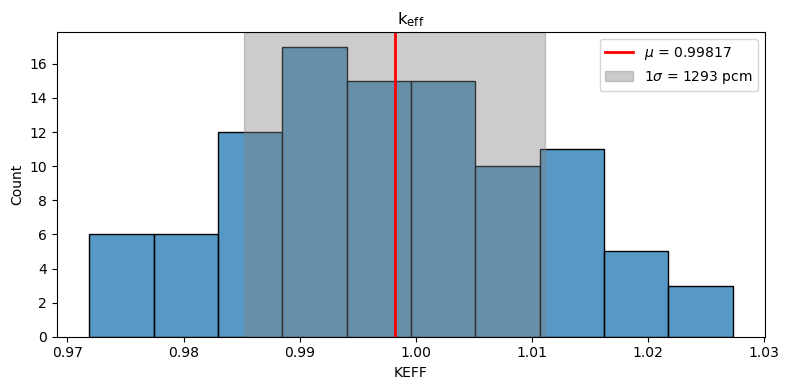

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))

data = df["KEFF"]

sns.histplot(data=data, bins=10, ax=ax)

loc = data.mean()
scale = data.std()
ax.axvline(loc, color="red", lw=2, label=rf"$\mu$ = {loc:.5f}")
ax.axvspan(loc - scale, loc + scale, color="gray", alpha=.4, label=rf"1$\sigma$ = {scale * 1e5:.0f} pcm")

ax.legend()
ax.set(title=r"k$_{\mathrm{eff}}$")
fig.tight_layout()

This histogram shows how keff varies across all stochastic samples.

- The red vertical line marks the sample mean.
- The gray shaded region represents ±1σ.
- The shape indicates the effect of nuclear data uncertainties.

## 📈 Distribution of Statistical Uncertainty (Δkeff)

OpenMC reports a Monte‑Carlo statistical uncertainty per simulation.

We convert it to pcm and plot its distribution.

This helps verify:

- Consistent convergence across runs
- Presence of outliers
- Typical precision of each simulation

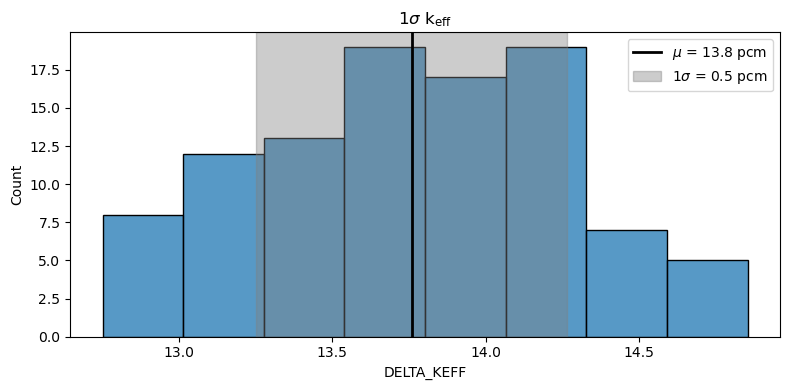

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))

noise= df["DELTA_KEFF"]

sns.histplot(data=noise * 1e5, bins=8, ax=ax)

loc = noise.mean() * 1e5
scale = noise.std() * 1e5
ax.axvline(loc, color="black", lw=2, label=rf"$\mu$ = {loc:.1f} pcm")
ax.axvspan(loc - scale, loc + scale, color="gray", alpha=.4, label=rf"1$\sigma$ = {scale:.1f} pcm")

ax.legend()
ax.set(title=r"1$\sigma$ k$_{\mathrm{eff}}$")

fig.tight_layout()

## 📊 KDE, Normal Fit, Q–Q Plot, and Normality Assessment

In this section, we examine the distribution of the sampled keff values using:

- Kernel Density Estimate (KDE)
- Normal distribution fit
- Q–Q plot
- Shapiro–Wilk normality test

These tools help determine whether the sampled keff values follow an approximately normal distribution (as expected when XS perturbations are small and independent).

The following code produces:

- **Left plot**: KDE of the keff samples plus a fitted normal PDF
- **Right plot**: Q–Q plot comparing empirical quantiles to a normal distribution

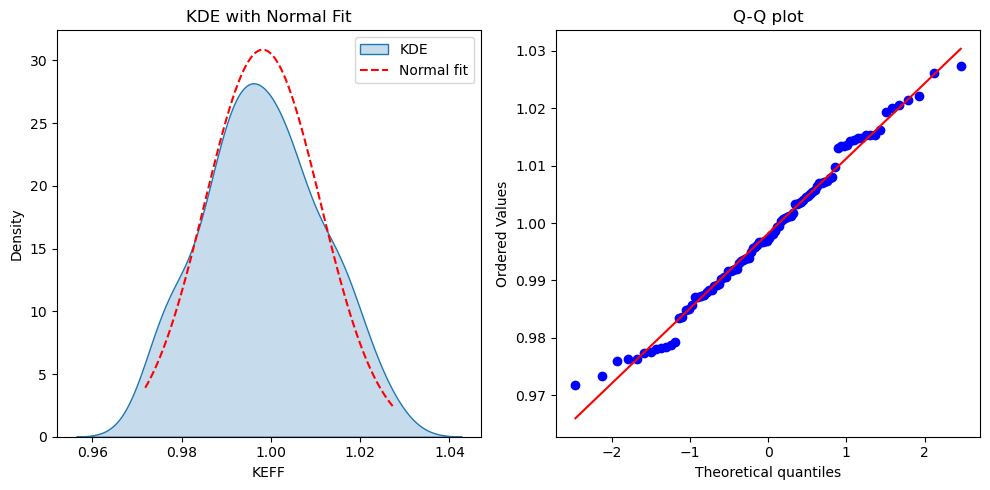

In [5]:
# data
data = df["KEFF"]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Plot KDE
ax = axs[0]
sns.kdeplot(data, fill=True, label="KDE", ax=ax)

# Fit a normal distribution to the samples
mu, std = data.mean(), data.std()
xmin, xmax = data.min(), data.max()
x = np.linspace(xmin, xmax, 100)
ax.plot(x, stats.norm.pdf(x, mu, std), 'r--', label="Normal fit")

# Labels
ax.set(xlabel="KEFF", ylabel="Density", title="KDE with Normal Fit")
ax.legend()

# Q-Q plot
ax = axs[1]
stats.probplot(data, dist="norm", plot=ax)
ax.set(title="Q-Q plot")

fig.tight_layout()

### KDE vs Normal Fit

- The KDE curve shows the empirical distribution of keff.
- The dashed red curve shows the best-fitting normal distribution.
- Good agreement suggests keff varies approximately normally due to stochastic XS perturbations.

### Q–Q Plot

- Points lying close to the diagonal line indicate normality.
- Systematic curvature implies skewness or heavy tails.

### Shapiro–Wilk Normality Test

In [6]:
stats.shapiro(data)

ShapiroResult(statistic=np.float64(0.9850183305067359), pvalue=np.float64(0.3185600440403974))

This returns:

- **W statistic**
- **p-value**

Interpretation:

- **p > 0.05** → fail to reject normality (data consistent with Gaussian).
- **p < 0.05** → evidence against normality.


## 🔁 Bootstrap Standard Error of Sample Estimate (Standard Deviation) 

We now compute a non‑parametric bootstrap estimate of the standard error (SE) of the standard deviation of keff.

Why bootstrap?

- Standard formulas assume normality.
- Bootstrap resampling does not assume any distribution.
- Instead, we repeatedly resample with replacement from the data and recompute the mean.
- The variability of these bootstrap statistics gives the standard error.

Step‑by‑step Explanation

### Start with the original data sample

This is the set of keff values generated by stochastic sampling of nuclear data.

$\{k_1, k_2, \ldots, k_{N}\}$

These values represent one observed dataset drawn from an unknown distribution.

### Resample with replacement N times

To mimic repeated sampling from the underlying (unknown) distribution:

- Choose a bootstrap size (e.g., M=10.000)
- For each replicate:

  - Draw N values with replacement from the original sample.
  - This forms one bootstrap sample.

Each bootstrap sample is of the same size (N), but because sampling is done with replacement, some values appear multiple times while others may not appear at all.

### Compute the statistic of interest

For each bootstrap sample, compute the statistic:


$\sigma_{k^{*(i)}} = \sqrt{\frac{1}{N-1}\sum_{j=1}^{N} \left( k^{*(i)}_j-\mu_{k^{*(i)}} \right)^2}$

This generates a bootstrap distribution of standard deviations:

$\{ \sigma_{k^{*(1)}}, \sigma_{k^{*(2)}}, \ldots, \sigma_{k^{*(M)}} \}$

### Estimate the sampling distribution

After all bootstrap replicates:

- The collection of all $\sigma_{k^{*(i)}}$ values approximates the **sampling distribution of the standard deviation**.
- The standard deviation of this collection gives the **bootstrap standard error of the sample standard deviation**.

This is a valid non‑parametric bootstrap and makes **no assumption of normality**.

In [7]:
data = df["KEFF"].values

# Bootstrap requires samples wrapped in a tuple
res = stats.bootstrap(
    data=(data,),
    statistic=np.std,
    vectorized=False,
    n_resamples=10000,
    method="basic",   # or "BCa" for bias-corrected accelerated intervals
    confidence_level=0.95
)

bootstrap_se = res.standard_error

print(f"Bootstrap SE of the sample standard deviation: {bootstrap_se * 1e5:.1f}")
print(f"95% CI (bootstrap): {res.confidence_interval.low * 1e5:.1f} – {res.confidence_interval.high * 1e5:.1f}")

Bootstrap SE of the sample standard deviation: 75.4
95% CI (bootstrap): 1149.8 – 1443.9


# 📘 Comparison of keff Distributions for Different Perturbation Subsets

In this section, we compare the impact of perturbing different **individual nuclear data components** on the effective multiplication factor (keff).

Four datasets are considered:

- **all** — all nuclear data components perturbed simultaneously
- **nubar** — only nubar(average neutrons per fission) perturbed
- **pfns** — only the prompt fission neutron spectrum (PFNS) perturbed
- **fiss_capt** — only fission and capture cross sections are perturbed (including correlations) 

The perturbed nuclear data files were generated on a different machine running `sandy` with the following commands:

**nubar**
```bash
python -m sandy.sampling U235.jeff40 --samples 100 --processes 10  --acer --temperatures 293.6 --mf 31
```

**pfns**
```bash
python -m sandy.sampling U235.jeff40 --samples 100 --processes 10  --acer --temperatures 293.6 --mf 35
```

**fiss_capt**
```bash
python -m sandy.sampling U235.jeff40 --samples 100 --processes 10  --acer --temperatures 293.6 --mf 33 --mt33 18 102
```

## 📥 Loading the Data

Repeat the loading process, but this time in a loop.

In [8]:
dfs = {}

keys = ["nubar", "pfns", "fiss_capt"]

In [9]:
dfs["all"] = df

for key in keys:
    folder = Path(f"u235_{key}")

    df_temp = {}
    for i in range(100):
        f = h5py.File(folder / f'statepoint.500_{i}.h5', 'r')
        df_temp[i] = f["k_combined"][:]
    df_temp = pd.DataFrame(df_temp, index=["KEFF", "DELTA_KEFF"]).T

    dfs[key] = df_temp

## 📊 Distribution of keff

Each subplot shows:

- Histogram of keff for that subset
- Mean value (red vertical line)
- ±1σ band (gray shaded region, in pcm)

This allows a direct visual comparison of how strongly each XS component contributes to the total uncertainty in keff.
Typically:

- The **all** case provides the baseline total propagated uncertainty
- The contribution of each subset should be smaller (within statistical noise)
- Each contribution carries the same statistical noise (determined by number of histories in openmc)
- If ony a few reactions are perturbed (e.g., fission and capture in **fiss_capt**), their correlations with other reactions are neglected.

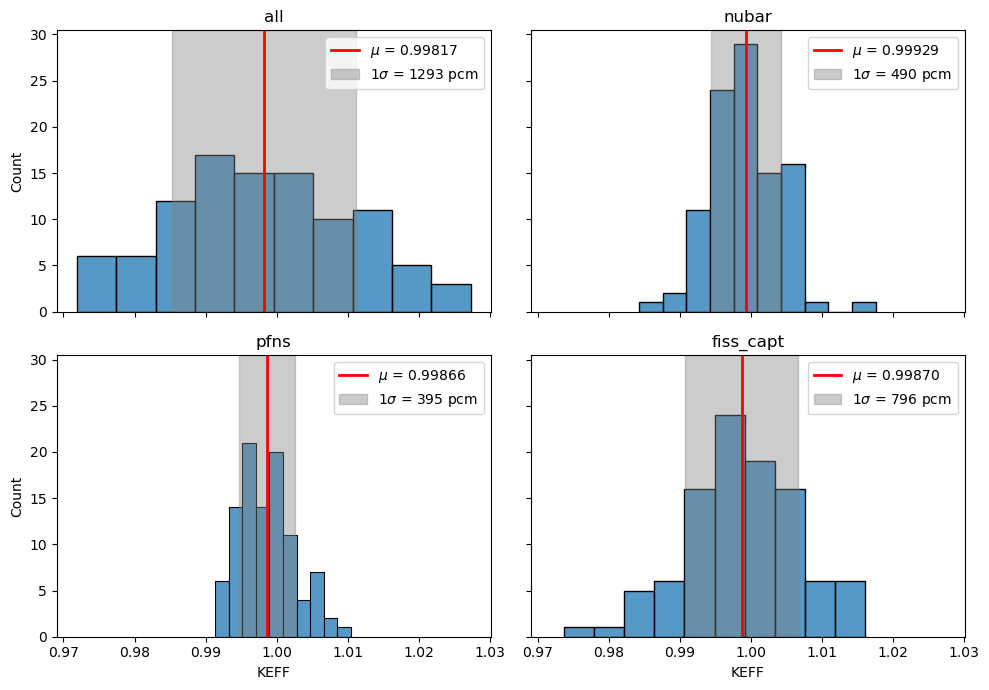

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)

map_ax = {
    "all":       (0, 0),
    "nubar":     (0, 1),
    "pfns":      (1, 0),
    "fiss_capt": (1, 1),
}

for key in dfs:
    ax = axs[map_ax[key]]

    data = dfs[key]["KEFF"]
    
    sns.histplot(data=data, bins=10, ax=ax)
    
    loc = data.mean()
    scale = data.std()
    ax.axvline(loc, color="red", lw=2, label=rf"$\mu$ = {loc:.5f}")
    ax.axvspan(loc - scale, loc + scale, color="gray", alpha=.4, label=rf"1$\sigma$ = {scale * 1e5:.0f} pcm")
    
    ax.legend()
    ax.set(title=rf"{key}")

fig.tight_layout()

## 📊 KDE, Normal Fit, Q–Q Plot, and Normality Assessment

We can examine the distribution of the sampled keff for each subset. Just change the key below.

In [11]:
key = "fiss_capt"   # we can change this

ShapiroResult(statistic=np.float64(0.9860328445610429), pvalue=np.float64(0.3759331722143127))

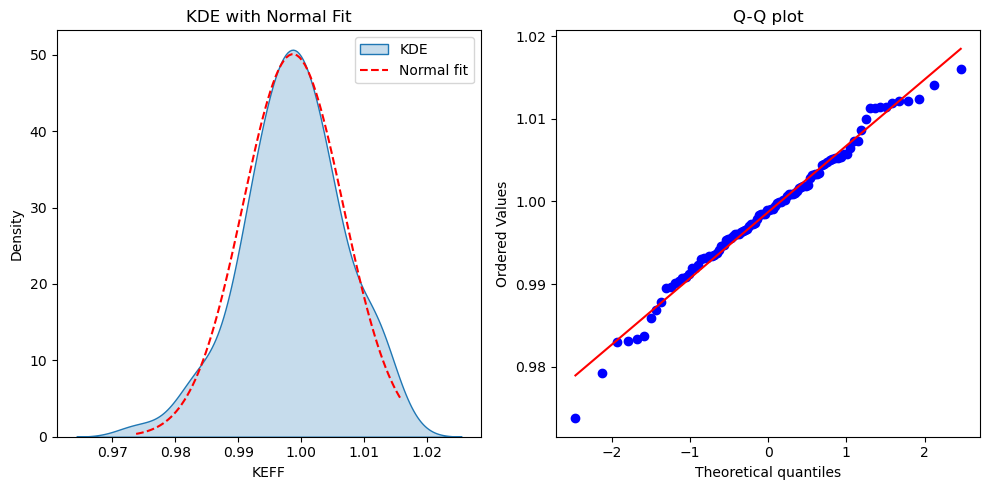

In [12]:
# data
data = dfs[key]["KEFF"]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Plot KDE
ax = axs[0]
sns.kdeplot(data, fill=True, label="KDE", ax=ax)

# Fit a normal distribution to the samples
mu, std = data.mean(), data.std()
xmin, xmax = data.min(), data.max()
x = np.linspace(xmin, xmax, 100)
ax.plot(x, stats.norm.pdf(x, mu, std), 'r--', label="Normal fit")

# Labels
ax.set(xlabel="KEFF", ylabel="Density", title="KDE with Normal Fit")
ax.legend()

# Q-Q plot
ax = axs[1]
stats.probplot(data, dist="norm", plot=ax)
ax.set(title="Q-Q plot")

fig.tight_layout()

stats.shapiro(data)